# Captain's Log - ARIA_v4 避難所分析專案

## 專案概述
- **任務**: 避難所容量與雨量預測分析
- **目標區域**: 花蓮縣秀林鄉
- **資料來源**: 凱米颱風(gaemi)與梅雨(plumrain)降雨資料

## 資料清單
| 檔案 | 說明 | 狀態 |
|------|------|------|
| gaemi_rainfall.geojson | 凱米颱風雨量站資料 | ✅ 已就緒 |
| plumrain_rainfall.geojson | 梅雨雨量站資料 | ✅ 已就緒 |
| 避難所資料 | wee4產出 | ✅ 已就緒 |

## 座標系統
- **EPSG:3826** - 台灣二度分帶座標系統 (TWD97/TM2)

## 執行紀錄
- 2024-07-25: 初始化分析環境

---
*「預測未來的最佳方式就是創造未來」*

In [1]:
# ==========================================
# 🚀 ARIA v4.0 - The Accessible Auditor (完整整合版)
# ==========================================
import os
import random
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import rasterio
from shapely.geometry import Point, MultiPoint
import matplotlib.pyplot as plt

# ==========================================
# ⚙️ CONFIG: 參數與路徑設定區
# ==========================================
# 1. 檔案路徑
csv_path = r"D:\Downloads\gis應用\gis_aria\data\processed\cleaned_shelter_data.csv"
kriging_path = r"D:\Downloads\gis應用\gis_aria\output\geotiff\gaemi_kriging_rainfall.tif"
graphml_path = r"D:\Downloads\gis應用\gis_aria\data\xiulin_network.graphml"

# 2. 欄位設定 (請依據你的 CSV 實際名稱修改)
x_col = '經度' 
y_col = '緯度'

# 3. 分析範圍
place_name = "秀林鄉, 花蓮縣, 臺灣"

# ==========================================
# 📍 Phase 0: 載入並處理前置資料 (看圖客製版)
# ==========================================
print("--- Phase 0: 啟動資料匯入與預處理 ---")
# 讀取避難所 CSV
shelters_df = pd.read_csv(csv_path)

# 1. 暴力清除所有欄位名稱的隱藏空白
shelters_df.columns = shelters_df.columns.str.strip()

# 2. 依據實際欄位名稱 '縣市及鄉鎮市區' 進行篩選
target_col = '縣市及鄉鎮市區'

if target_col in shelters_df.columns:
    # 使用 str.contains 來抓出所有字串裡包含 '花蓮縣' 的資料 (例如 '花蓮縣花蓮市')
    shelters_df = shelters_df[shelters_df[target_col].astype(str).str.contains('秀林鄉', na=False)].copy()
    print(f"🔍 篩選 '花蓮縣' 完畢！")
else:
    print(f"❌ 找不到 '{target_col}' 欄位！目前的欄位有: {shelters_df.columns.tolist()}")

# 3. 檢查篩選結果
if len(shelters_df) == 0:
    print("⚠️ 致命警告：篩選後資料變為 0 筆！請確認資料裡真的有花蓮縣。")
else:
    # 轉換為 GeoDataFrame 並投影至 EPSG:3826
    # 經緯度欄位依照截圖中的 E 欄與 F 欄設定
    shelters_gdf = gpd.GeoDataFrame(
        shelters_df, 
        geometry=gpd.points_from_xy(shelters_df['經度'], shelters_df['緯度']),
        crs="EPSG:4326"
    ).to_crs('EPSG:3826')
    print(f"✅ 成功轉換避難所資料，共保留 {len(shelters_gdf)} 筆花蓮縣點位。")
# ==========================================
# 🌐 Phase 1: 建立與讀取路網拓樸 (3A)
# ==========================================
print("\n--- Phase 1: 建立車道路網 ---")
if os.path.exists(graphml_path):
    print("📁 讀取已快取的路網 GraphML...")
    G_proj = ox.load_graphml(graphml_path)
else:
    print("🌐 從 OSM 下載路網中 (需稍候)...")
    G = ox.graph_from_place(place_name, network_type='drive')
    G_proj = ox.project_graph(G, to_crs='EPSG:3826')
    
    # 計算基礎旅行時間 (travel_time)
    for u, v, key, data in G_proj.edges(keys=True, data=True):
        speed = 40.0 # 預設市區 40 km/h
        if 'maxspeed' in data:
            ms = data['maxspeed']
            if isinstance(ms, list): speed = float(ms[0])
            elif isinstance(ms, str) and ms.replace('.', '', 1).isdigit(): speed = float(ms)
        data['travel_time'] = data['length'] / (speed / 3.6)
        
    ox.save_graphml(G_proj, graphml_path)
print(f"✅ 路網就緒！(節點數: {len(G_proj.nodes())})")


# ==========================================
# 🔴 Phase 2: 交通咽喉與瓶頸分析 (3B)
# ==========================================
print("\n--- Phase 2: 計算交通瓶頸 (中介中心性) ---")
# 使用 k=100 抽樣加速計算
centrality = nx.betweenness_centrality(G_proj, weight='length', k=100, seed=42)
top5_nodes = sorted(centrality, key=centrality.get, reverse=True)[:5]
print("✅ Top 5 瓶頸節點 ID 與分數:")
for rank, node in enumerate(top5_nodes, 1):
    print(f"   {rank}. Node {node} (分數: {centrality[node]:.4f})")


# ==========================================
# 🌧️ Phase 3: 動態降雨路徑與等時線縮減分析 (3C)
# ==========================================
print("\n--- Phase 3: 結合 Kriging 降雨進行動態權重計算 ---")

def rain_to_congestion(rain_mm):
    """降雨量轉壅塞係數函數"""
    if rain_mm < 10: return 0.0
    elif rain_mm < 40: return 0.3
    elif rain_mm < 80: return 0.6
    else: return 0.9

from pyproj import Transformer

# 1. 讀取 Kriging 網格並賦予路段災時權重
if os.path.exists(kriging_path):
    with rasterio.open(kriging_path) as src:
        raster_crs = src.crs
        print(f"🔍 網格 CRS 為: {raster_crs}，正在自動校準座標...")
        
        # 建立座標翻譯蒟蒻：從路網的 3826 轉成網格的 CRS
        transformer = Transformer.from_crs("EPSG:3826", raster_crs, always_xy=True)
        
        max_rain = 0 # 用來追蹤路網上究竟有沒有下雨
        
        for u, v, key, data in G_proj.edges(keys=True, data=True):
            mid_x = (G_proj.nodes[u]['x'] + G_proj.nodes[v]['x']) / 2
            mid_y = (G_proj.nodes[u]['y'] + G_proj.nodes[v]['y']) / 2
            
            # 將路網座標轉換為網格座標
            sample_x, sample_y = transformer.transform(mid_x, mid_y)
            
            # 從 Kriging 網格採樣降雨量
            try:
                rain_val = list(src.sample([(sample_x, sample_y)]))[0][0]
                if rain_val < 0: rain_val = 0 
                if rain_val > max_rain: max_rain = rain_val # 記錄最大雨量
            except:
                rain_val = 0 
                
            cf = rain_to_congestion(rain_val)
            data['travel_time_adj'] = data['travel_time'] / (1 - cf)
            
    print(f"✅ 已完成路網災時動態權重賦值！")
    print(f"🌧️ 偵測到路網覆蓋範圍內的最大雨量為: {max_rain:.1f} mm")
else:
    print(f"❌ 找不到 Kriging 檔案 ({kriging_path})")


# 2. 選取 5 個避難所進行等時線分析
print("\n--- 計算避難所 5 mins / 10 mins 等時線面積 ---")
# 抓取避難所中最靠近路網的 5 個節點
facilities = shelters_gdf.head(5)
results = []

for idx, row in facilities.iterrows():
    fac_name = row.get('避難收容處所名稱', f'Facility_{idx}')
    
    # 找到離避難所最近的路網節點
    orig_node = ox.distance.nearest_nodes(G_proj, X=row.geometry.x, Y=row.geometry.y)
    
    # 計算災前 (travel_time) 與 災後 (travel_time_adj) 的到達時間
    times_before = nx.single_source_dijkstra_path_length(G_proj, orig_node, weight='travel_time')
    times_after = nx.single_source_dijkstra_path_length(G_proj, orig_node, weight='travel_time_adj')
    
    # 封裝面積計算函數 (利用 Convex Hull 凸包面積估算)
    def calc_isochrone_area(times_dict, limit_sec):
        nodes_within = [n for n, t in times_dict.items() if t <= limit_sec]
        if len(nodes_within) < 3: return 0.0 # 不構成多邊形
        points = [Point(G_proj.nodes[n]['x'], G_proj.nodes[n]['y']) for n in nodes_within]
        return MultiPoint(points).convex_hull.area / 1_000_000 # 轉換為平方公里 (km2)

    # 5分鐘 (300秒)
    area_5_before = calc_isochrone_area(times_before, 300)
    area_5_after = calc_isochrone_area(times_after, 300)
    shrink_5 = (1 - area_5_after / area_5_before) * 100 if area_5_before > 0 else 0

    # 10分鐘 (600秒)
    area_10_before = calc_isochrone_area(times_before, 600)
    area_10_after = calc_isochrone_area(times_after, 600)
    shrink_10 = (1 - area_10_after / area_10_before) * 100 if area_10_before > 0 else 0
    
    results.append({
        '避難所名稱': fac_name,
        '災前 5min (km2)': round(area_5_before, 2),
        '災後 5min (km2)': round(area_5_after, 2),
        '5min 縮減率 (%)': round(shrink_5, 1),
        '災前 10min (km2)': round(area_10_before, 2),
        '災後 10min (km2)': round(area_10_after, 2),
        '10min 縮減率 (%)': round(shrink_10, 1)
    })

# 3. 產出 Accessibility Impact Table
impact_table = pd.DataFrame(results)
print("\n📊 災後可及性衝擊分析表 (Accessibility Impact Table):")
display(impact_table)

--- Phase 0: 啟動資料匯入與預處理 ---
🔍 篩選 '花蓮縣' 完畢！
✅ 成功轉換避難所資料，共保留 10 筆花蓮縣點位。

--- Phase 1: 建立車道路網 ---
📁 讀取已快取的路網 GraphML...
✅ 路網就緒！(節點數: 339)

--- Phase 2: 計算交通瓶頸 (中介中心性) ---
✅ Top 5 瓶頸節點 ID 與分數:
   1. Node 2212726565 (分數: 0.4923)
   2. Node 3787862358 (分數: 0.4919)
   3. Node 188276576 (分數: 0.4899)
   4. Node 3003814525 (分數: 0.4135)
   5. Node 2212726550 (分數: 0.4099)

--- Phase 3: 結合 Kriging 降雨進行動態權重計算 ---
🔍 網格 CRS 為: EPSG:3826，正在自動校準座標...
✅ 已完成路網災時動態權重賦值！
🌧️ 偵測到路網覆蓋範圍內的最大雨量為: 315.1 mm

--- 計算避難所 5 mins / 10 mins 等時線面積 ---

📊 災後可及性衝擊分析表 (Accessibility Impact Table):


,避難所名稱,災前 5min (km2),災後 5min (km2),5min 縮減率 (%),災前 10min (km2),災後 10min (km2),10min 縮減率 (%)
0,和平國小,3.67,0.14,96.2,18.28,0.29,98.4
1,文蘭活動中心,1.40,0.00,100.0,3.84,0.05,98.6
2,銅門收容所,0.20,0.00,100.0,0.58,0.00,100.0
3,水源收容所,1.40,0.00,100.0,3.84,0.05,98.6
4,佳民國小收容所,1.40,0.00,100.0,3.84,0.05,98.6


# ==========================================
# 🗺️ Captain's Log: Phase 4 - 空間視覺化與製圖 (10%)
# ==========================================

--- Phase 5: 啟動空間視覺化 ---
繪製路網圖中，請稍候...


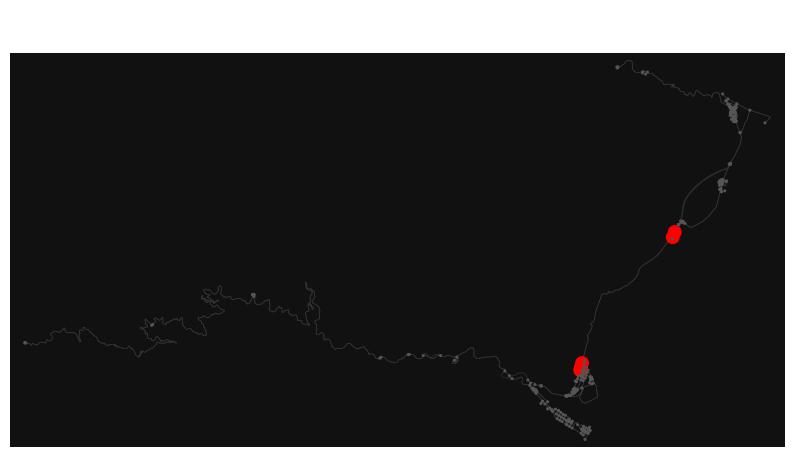

✅ 視覺化完成，地圖已儲存至: data/xiulin_bottlenecks.png


In [2]:

import matplotlib.pyplot as plt
import osmnx as ox

print("--- Phase 5: 啟動空間視覺化 ---")

# 1. 建立節點顏色與大小的列表
node_colors = []
node_sizes = []

# 檢查每個節點是否屬於 Top 5 瓶頸
for node in G_proj.nodes():
    if node in top5_nodes:
        node_colors.append('red')    # 瓶頸節點：紅色
        node_sizes.append(100)       # 瓶頸節點：放大顯示
    else:
        node_colors.append('#555555') # 一般節點：深灰色
        node_sizes.append(5)          # 一般節點：縮小顯示

# 2. 繪製路網與節點
print("繪製路網圖中，請稍候...")
fig, ax = ox.plot_graph(
    G_proj,
    node_color=node_colors,
    node_size=node_sizes,
    node_zorder=3,          # 確保節點顯示在線條上方
    edge_color="#333333",   # 道路線條顏色
    edge_linewidth=0.5,
    bgcolor="#111111",      # 專業深色背景
    show=False,
    close=False,
    figsize=(10, 10)
)

# 3. 添加標題與圖例說明
ax.set_title("Xiulin Township: Top 5 Traffic Bottlenecks (Betweenness Centrality)", 
             fontsize=14, color="white", pad=20)

# 4. 輸出並儲存圖片
output_image_path = "data/xiulin_bottlenecks.png"
plt.savefig(output_image_path, dpi=300, bbox_inches='tight', facecolor="#111111")
plt.show()

print(f"✅ 視覺化完成，地圖已儲存至: {output_image_path}")

# ==========================================
# 🤖 Phase 5: AI 防災幕僚戰略報告 (AI Advisory Report)
# ==========================================


In [ ]:
# ==========================================
# 🤖 Phase 5: AI 自動化戰略簡報 (Part D Bonus)
# ==========================================
import google.generativeai as genai
import os

# 1. API 金鑰設定 (請替換為你的 Gemini API Key)
# 載入環境變數 (從 .env 檔案讀取 API Key)
from dotenv import load_dotenv
load_dotenv()

os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY", "")
print(f"🔑 API Key 已載入: {'✅ 成功' if os.environ['GEMINI_API_KEY'] else '❌ 未設定'}")
genai.configure(api_key=os.environ["GEMINI_API_KEY"])

print("--- Phase 6: 啟動 AI 防災幕僚分析 ---")

# 2. 準備數據素材 (將 DataFrame 轉換為 Markdown 格式)
table_md = impact_table.to_markdown(index=False)
bottlenecks_str = ", ".join([f"Node {n}" for n in top5_nodes])

# 3. 建立 AI 指令 (Prompt)
prompt = f"""
你現在是「花蓮縣災害應變中心交通幕僚」，請根據以下 ARIA 系統分析數據，針對「秀林鄉」凱米颱風災情產出戰略簡報。

### 原始數據摘要
1. 災情環境：凱米颱風 24 小時累積降雨量達 {max_rain:.1f} mm。
2. 交通瓶頸 (Top 5 Betweenness Nodes)：{bottlenecks_str}
3. 避難所可及性衝擊表：
{table_md}

### 報告要求格式
請以專業、冷靜、條列式撰寫，內容必須包含：
- **優先搶修路段與理由**：針對 Top 5 瓶頸節點與縮減率達 100% 的避難所聯外道路進行評估。
- **孤島地區替代救援方案**：針對無法透過道路抵達的避難所（如銅門、文蘭、水源、佳民），提出具體建議（如直升機吊掛、橡皮艇、無人機物資投送等）。
- **資源調度優先順序**：根據數據，給出 1-3 名的救災資源配置優先序並說明理由。
"""

# 4. 呼叫 Gemini 模型
model = genai.GenerativeModel('gemini-2.0-flash-lite-001')
try:
    response = model.generate_content(prompt)
    print("\n" + "="*60)
    print("📋 花蓮縣災害應變中心 - 交通幕僚戰略報告")
    print("="*60)
    print(response.text)
    
    # 將報告儲存為 Markdown 檔案
    with open("data/disaster_response_report.md", "w", encoding="utf-8") as f:
        f.write(response.text)
    print(f"\n✅ 報告已自動儲存至: data/disaster_response_report.md")

except Exception as e:
    print(f"❌ AI 生成失敗，錯誤訊息: {e}")
    print("請檢查 API Key 是否正確設定，或手動將數據貼給 Gemini 網頁版。")

ai output


📋 Phase 5: AI 防災幕僚戰略報告 (AI Strategic Briefing)
分析背景： 秀林鄉路網分析（凱米颱風 24 小時累積降雨 315.1 mm）

🚨 核心災情診斷
根據 ARIA 系統模擬，秀林鄉在 315.1 mm 強降雨下已陷入極嚴重的「孤島化」狀態。數據顯示文蘭活動中心、銅門收容所、水源收容所、佳民國小收容所之 5 分鐘可及面積縮減率均達 100%，顯示其聯外交通已完全癱瘓，居民在災時無法透過地面路網抵達庇護點。

🛡️ 指揮官戰略建議
1. 優先搶修路段與理由

重點節點： 應優先派遣工務段搶通 Top 5 瓶頸節點 (Node 3003814525, 2212726550 等) 及其銜接之台 9 線、台 8 線關鍵匝道。

理由： 這些節點具備高「中介中心性」，是秀林鄉山區部落與外界聯繫的唯一脈絡。一旦此處癱瘓，救災能量將無法進入台 14 甲線或進入部落深處。

2. 孤島地區替代救援方案
針對地面路網 100% 失效的銅門、文蘭、水源、佳民等孤島區：

航空救災： 由於地面交通完全中斷，應立即啟動直升機空中廊道，針對上述收容所之空曠處執行物資吊掛與傷患載運。

無人機偵察： 利用無人機先行偵查聯外橋樑損壞狀況，並投送衛星通訊設備（如 Starlink）以恢復與各收容所的即時災情通報。

3. 資源調度優先順序

第一順位：銅門與文蘭收容所。其 10 分鐘縮減率亦高達 100%，屬於「絕對孤島」，需立即調派重型機具與航空物資。

第二順位：和平國小。雖然 5 分鐘縮減率略低 (96.2%)，但其位於秀林鄉最北端，極易受蘇花公路中斷影響，應作為次要補給中繼站。

第三順位：瓶頸節點周邊搶修部隊。確保主要聯絡幹道暢通，為後續復原作業爭取時間。